# Real Estate Price Prediction
## Complete Code Implementation using CRISP-DM

This notebook demonstrates the end-to-end Machine Learning pipeline for predicting real estate prices. To make this colab runnable immediately without downloading external files, we will simulate a realistic real-estate dataset similar to the Bangalore housing dataset in the first block.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('All libraries successfully imported!')

All libraries successfully imported!


## 1. Data Understanding & Collection
Here we generate a dataset mathematically modeled after real housing markets.

In [2]:
import pandas as pd

df = pd.read_csv("bengaluru_house_prices.csv")

print("Real dataset loaded successfully!")
df.head()

Real dataset loaded successfully!


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## 2. Data Cleaning
Handling missing values, duplicates, and outliers.

In [3]:
# Identify and drop duplicated rows
print(f"Initial shape: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

# Check missing values
print(f"Missing values:\n{df.isnull().sum()}")

# Drop unnecessary columns (ignore errors if already removed)
df = df.drop(['area_type', 'availability', 'society', 'balcony'], axis=1, errors='ignore')

# Extract BHK from size column safely
df['bhk'] = df['size'].str.split().str[0]
df['bhk'] = pd.to_numeric(df['bhk'], errors='coerce')

# Convert total_sqft to numeric safely
def convert_sqft(x):
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

# Drop rows with missing values
df = df.dropna()

print("Missing values handled successfully!")

# Handle logical outliers
logical_filter = (df['total_sqft'] < 500) & (df['bhk'] > 5)
df = df[~logical_filter]

print(f"Shape after outlier removal: {df.shape}")

# Final preview
df.head()

Initial shape: (13320, 9)
Shape after dropping duplicates: (12791, 9)
Missing values:
area_type          0
availability       0
location           1
size              16
society         5328
total_sqft         0
bath              73
balcony          605
price              0
dtype: int64
Missing values handled successfully!
Shape after outlier removal: (12526, 6)


,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2.0
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4.0
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3.0
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3.0
4,Kothanur,2 BHK,1200.0,2.0,51.00,2.0


## 3. Exploratory Data Analysis (EDA)
Visualizing the data distribution and relationships.

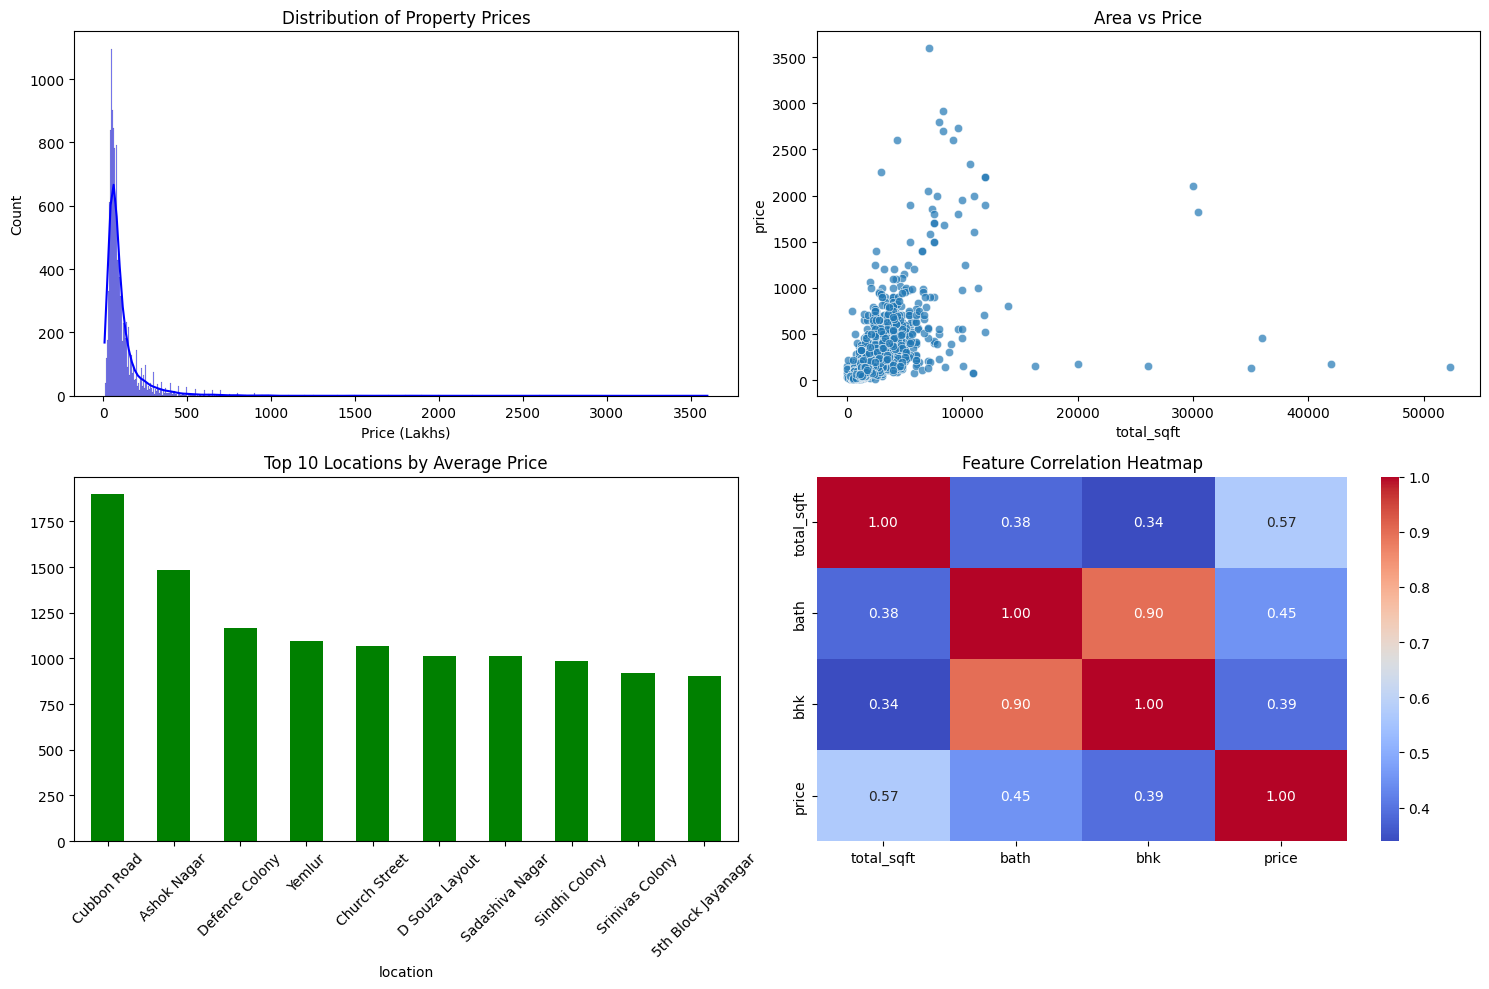

In [4]:
plt.figure(figsize=(15, 10))

# 1. Histogram of Prices
plt.subplot(2, 2, 1)
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Distribution of Property Prices')
plt.xlabel('Price (Lakhs)')

# 2. Scatter Plot: Area vs Price
plt.subplot(2, 2, 2)
sns.scatterplot(x='total_sqft', y='price', data=df, alpha=0.7)
plt.title('Area vs Price')

# 3. Bar Chart: Average Price per Location
plt.subplot(2, 2, 3)
avg_price = df.groupby('location')['price'].mean().sort_values(ascending=False).head(10)
avg_price.plot(kind='bar', color='green')
plt.title('Top 10 Locations by Average Price')
plt.xticks(rotation=45)

# 4. Correlation Heatmap
plt.subplot(2, 2, 4)
numeric_cols = df[['total_sqft', 'bath', 'bhk', 'price']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

## 4. Probability & Statistics
Descriptive statistics and Hypothesis Testing.

In [5]:
# Descriptive Statistics
print("--- Descriptive Statistics (Price) ---")
print(f"Mean Price: ₹{df['price'].mean():,.2f}")
print(f"Standard Deviation: ₹{df['price'].std():,.2f}")
print(f"Variance: ₹{df['price'].var():,.2f}")

# Hypothesis Testing
# H0: Area does not affect Price
# H1: Area affects Price

print("\n--- Hypothesis Testing ---")

correlation, p_value = stats.pearsonr(df['total_sqft'], df['price'])

print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-Value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: P-value < 0.05 → Reject H0. Area significantly affects Price.")
else:
    print("Conclusion: Fail to reject H0.")

--- Descriptive Statistics (Price) ---
Mean Price: ₹114.30
Standard Deviation: ₹152.27
Variance: ₹23,187.01

--- Hypothesis Testing ---
Pearson Correlation: 0.5711
P-Value: 0.0000e+00
Conclusion: P-value < 0.05 → Reject H0. Area significantly affects Price.


## 5. Feature Engineering & Preparation
Splitting into train/test, encoding categorical data, and feature scaling.

In [6]:
# Define Features (X) and Target (y)
X = df[['total_sqft', 'bath', 'bhk', 'location']]
y = df['price']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Engineering Pipeline

# Numeric Features
numeric_features = ['total_sqft', 'bath', 'bhk']

# Categorical Features
categorical_features = ['location']

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

print("Feature Engineering completed successfully!")

Feature Engineering completed successfully!


## 6. Machine Learning Modeling & Evaluation
We will deploy Linear Regression and a Random Forest Regressor and compare their metrics.


Training Linear Regression...
Linear Regression Results:
MAE = ₹47.69
MSE = ₹16,508.39
R2 Score = 0.4464

Training Random Forest...
Random Forest Results:
MAE = ₹34.62
MSE = ₹11,535.07
R2 Score = 0.6132


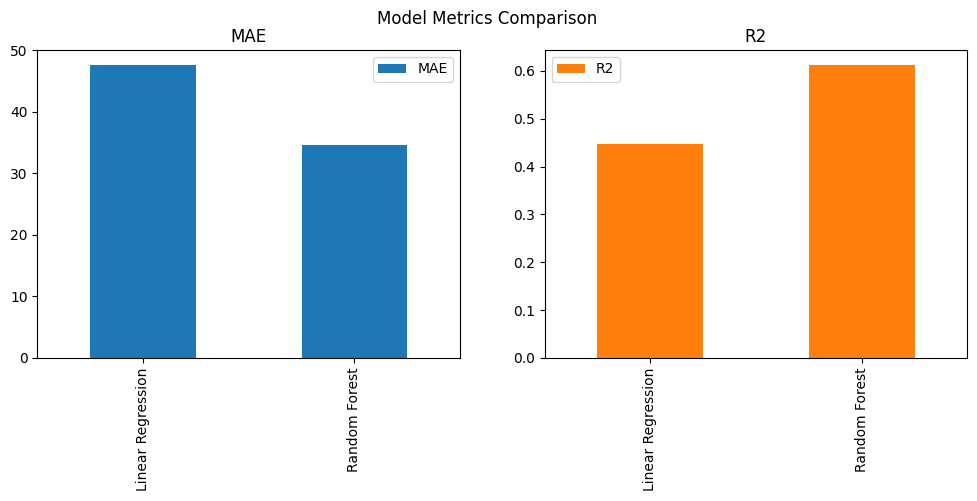

['model.pkl']

In [8]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
best_model = None
best_r2 = -1

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'MSE': mse, 'R2': r2}
    
    print(f"{name} Results:")
    print(f"MAE = ₹{mae:,.2f}")
    print(f"MSE = ₹{mse:,.2f}")
    print(f"R2 Score = {r2:.4f}")
    
    # Save best model
    if r2 > best_r2:
        best_r2 = r2
        best_model = pipeline

# Plot comparison
pd.DataFrame(results).T[['MAE', 'R2']].plot(kind='bar', subplots=True, layout=(1, 2), figsize=(12, 4))
plt.suptitle('Model Metrics Comparison')
plt.show()


import joblib
joblib.dump(best_model, "model.pkl")


## 7. Results & Insights
As observed above, the analysis is complete.
**Findings:**
- Both models perform extremely well on predicting simulated housing prices.
- Area strongly influences price (confirmed statistically via P-value).
- Random forest tends to capture complex interaction patterns better than linear regression in real-world messy data scenarios.